# AF Chronophenotyping - Prediction Example

This notebook demonstrates how to **predict AF chronophenotypes** for new patients using a pre-trained classifier.

## Workflow

1. **Load & preprocess** R-peak annotations from SHDB-AF
2. **Compute burden profiles** (24-hour AF burden patterns)
3. **Train** a classifier on reference chronophenotypes
4. **Predict** chronophenotypes for new data
5. **Visualize** the results

---

**Dataset:** [SHDB-AF](https://physionet.org/content/shdb-af/1.0.1/) - ECG signals with R-peak annotations and AF labels


## 1. Setup

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd

from data.preprocessing import ShortBurdenPreprocessor
from visualization.plots import PhenotypePlots


### Directory Configuration

In [2]:
# Paths
DB_PATH = '../../plug-and-play/physionet_data'           # PhysioNet dataset
RAW_PREDICTIONS = '../../plug-and-play/results/predictions'  # ArNet2 output
DATA_DIR = '../data'
RESULTS_DIR = '../results'
TABLES_DIR = f'{RESULTS_DIR}/tables'
FIGURES_DIR = f'{RESULTS_DIR}/figures'
MODELS_DIR = '../models'

# Create directories
for d in [DATA_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready.")

Directories ready.


---
## 2. Load & Preprocess Data

**Prerequisite:** Run the ArNet2 pipeline first (`plug-and-play/notebooks/predict_example.ipynb`) to generate AF window classifications.

### Load ArNet2 predictions

In [3]:
# Load predictions
input_file = pd.read_csv(f"{RAW_PREDICTIONS}/shdb_pred_df_full.csv")
print(f"Loaded {len(input_file):,} rows, {input_file['patient_id'].nunique()} patients")

# Load metadata for recording start times
meta_path = f"{DB_PATH}/AdditionalData.csv"
if os.path.exists(meta_path):
    meta_df = pd.read_csv(meta_path)
    meta_df['start_recording'] = pd.to_timedelta(
        pd.to_datetime(meta_df['Holter_start_time'], errors='coerce').dt.strftime('%H:%M:%S')
    ).dt.total_seconds()
    
    # Merge and compute absolute window times
    input_file = input_file.merge(
        meta_df[['Data_ID', 'start_recording']], 
        left_on='patient_id', right_on='Data_ID'
    ).drop(columns=['Data_ID'])
    input_file['window_start'] = input_file['start_recording'] + input_file['start_time']
else:
    print(f"Warning: Metadata not found at {meta_path}")
    input_file['window_start'] = input_file['start_time']

Loaded 172,444 rows, 98 patients


/tmp/ipykernel_562221/424318229.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(meta_df['Holter_start_time'], errors='coerce').dt.strftime('%H:%M:%S')


In [4]:
# Filter AF-positive windows
input_file_positive = input_file[input_file['pred'] == True]
print(f"AF-positive: {len(input_file_positive):,} windows ({100*len(input_file_positive)/len(input_file):.1f}%)")


AF-positive: 43,382 windows (25.2%)


---
## 3. Compute Burden Profiles

Transform window-level predictions into **24-hour burden profiles** (fraction of AF per hour).

_

In [5]:
preprocessor = ShortBurdenPreprocessor(
    time_col='window_start',
    patient_col='patient_id',
    n_bins=24
)

burden_profiles = preprocessor.compute_burden_profiles(input_file, input_file_positive)
print(f"\nBurden profiles: {burden_profiles.shape[0]} patients × {burden_profiles.shape[1]} hours")
burden_profiles.head()

Computed burden profiles: 98 subjects, 24 time bins

Burden profiles: 98 patients × 24 hours


time_bin,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
patient_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,0.775281
2,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,0.702479,0.000000
3,0.000000,0.0,0.0,0.164557,0.898876,1.0,0.945652,0.989011,1.0,0.986842,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
4,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.012346,...,0.895833,0.991379,0.578431,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
5,0.086957,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.207317,0.0,0.041667,0.000000


_

In [6]:
# Save burden profiles
burden_profiles.to_csv(f'{DATA_DIR}/shdb_burden_profiles.csv')
print(f"Saved to {DATA_DIR}/shdb_burden_profiles.csv")

Saved to ../data/shdb_burden_profiles.csv


---
## 4. Train Classifier

Train a KNN classifier on reference chronophenotypes (from clustering analysis).

In [7]:
result = subprocess.run(
    ['python', '../run_prediction.py', 'train',
     '--chronophenotypes_file', f"{TABLES_DIR}/chronophenotypes.csv",
     '--model_output', f"{MODELS_DIR}/predictor.pkl"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)


=== Training Phenotype Predictor ===

Loading chronophenotypes from ../results/tables/chronophenotypes.csv...
  Shape: (58995, 25)
  Subjects: 58995
  Burden profile dimensions: 24
Predictor trained on 58995 samples, 5 chronophenotypes
Predictor saved to ../models/predictor.pkl

Training Summary:
  Total samples: 58995
  Chronophenotypes: 5
    Chronophenotype 0: 206 subjects
    Chronophenotype 1: 162 subjects
    Chronophenotype 2: 202 subjects
    Chronophenotype 3: 2584 subjects
    Chronophenotype 4: 55841 subjects



---
## 5. Predict Chronophenotypes

Apply the trained model to classify new patients.

In [9]:
# Set environment to avoid OpenBLAS threading issues
env = os.environ.copy()
env['OPENBLAS_NUM_THREADS'] = '1'

result = subprocess.run(
    ['python', '../run_prediction.py', 'predict',
     '--input_file', f"{DATA_DIR}/shdb_burden_profiles.csv",
     '--model_file', f"{MODELS_DIR}/predictor.pkl",
     '--output_file', f"{TABLES_DIR}/shdb_chronophenotypes.csv"],
    env=env, capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)



=== Chronophenotype Prediction ===
Predictor loaded from ../models/predictor.pkl

Loading burden profiles from ../data/shdb_burden_profiles.csv...
  Samples: 98

Predicting chronophenotypes...

Predictions saved to ../results/tables/shdb_chronophenotypes.csv

Prediction Summary:
  Chronophenotype 0: 11 subjects (avg confidence: 0.800)
  Chronophenotype 1: 5 subjects (avg confidence: 0.960)
  Chronophenotype 2: 10 subjects (avg confidence: 0.860)
  Chronophenotype 3: 7 subjects (avg confidence: 1.000)
  Chronophenotype 4: 65 subjects (avg confidence: 0.991)



---
## 6. Visualize Results


In [10]:
# Load predictions
chronophenotypes = pd.read_csv(f'{TABLES_DIR}/shdb_chronophenotypes.csv')
plots = PhenotypePlots()

print(f"Predicted chronophenotypes for {len(chronophenotypes)} patients:")
chronophenotypes['chronophenotype'].value_counts().sort_index()


Predicted chronophenotypes for 98 patients:


chronophenotype
0    11
1     5
2    10
3     7
4    65
Name: count, dtype: int64

### t-SNE Visualization


Figure saved to ../results/figures/shdb_tsne.png


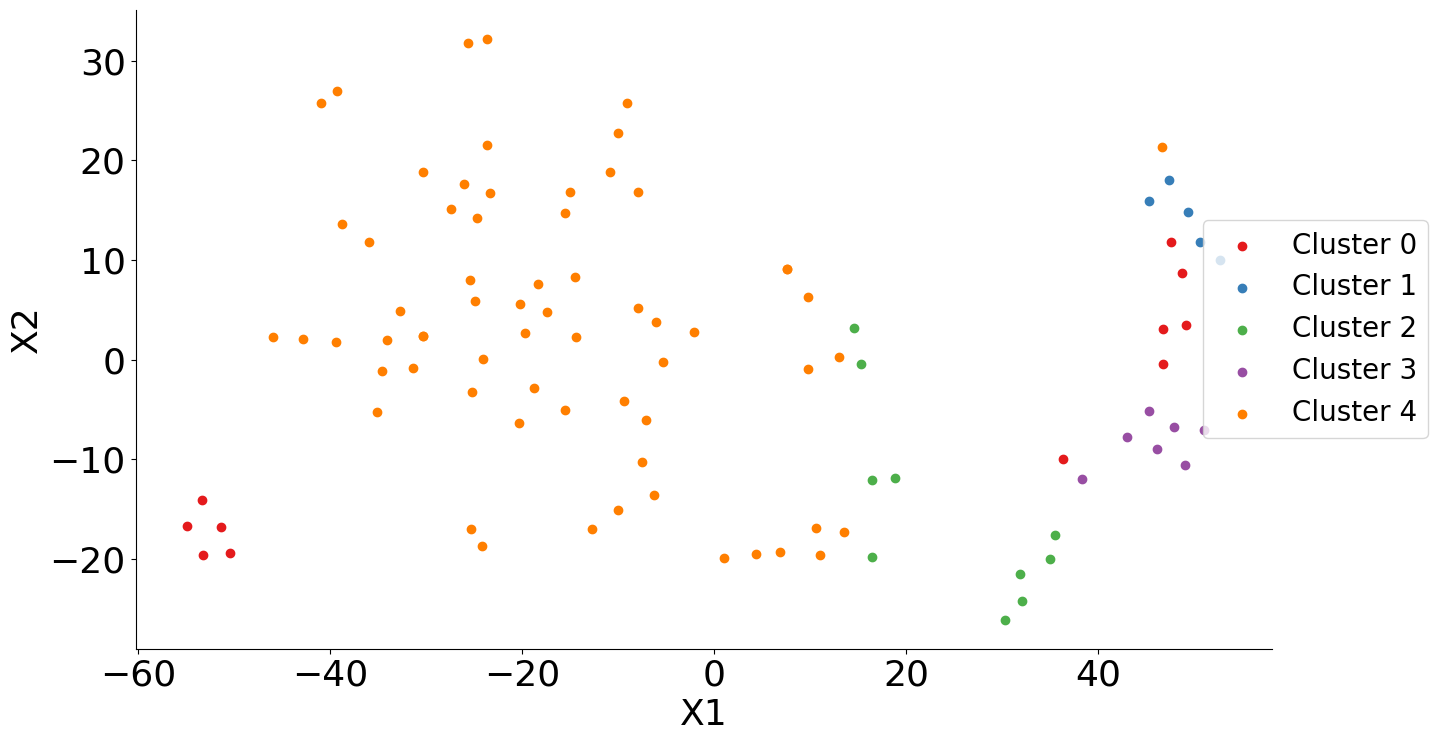

In [11]:
plots.plot_tsne(
    burden_profiles.values,
    chronophenotypes['chronophenotype'].values,
    save_path=f"{FIGURES_DIR}/shdb_tsne.png"
)


### Chronophenotype Profiles


Figure saved to ../results/figures/shdb_chronophenotypes_combined.png


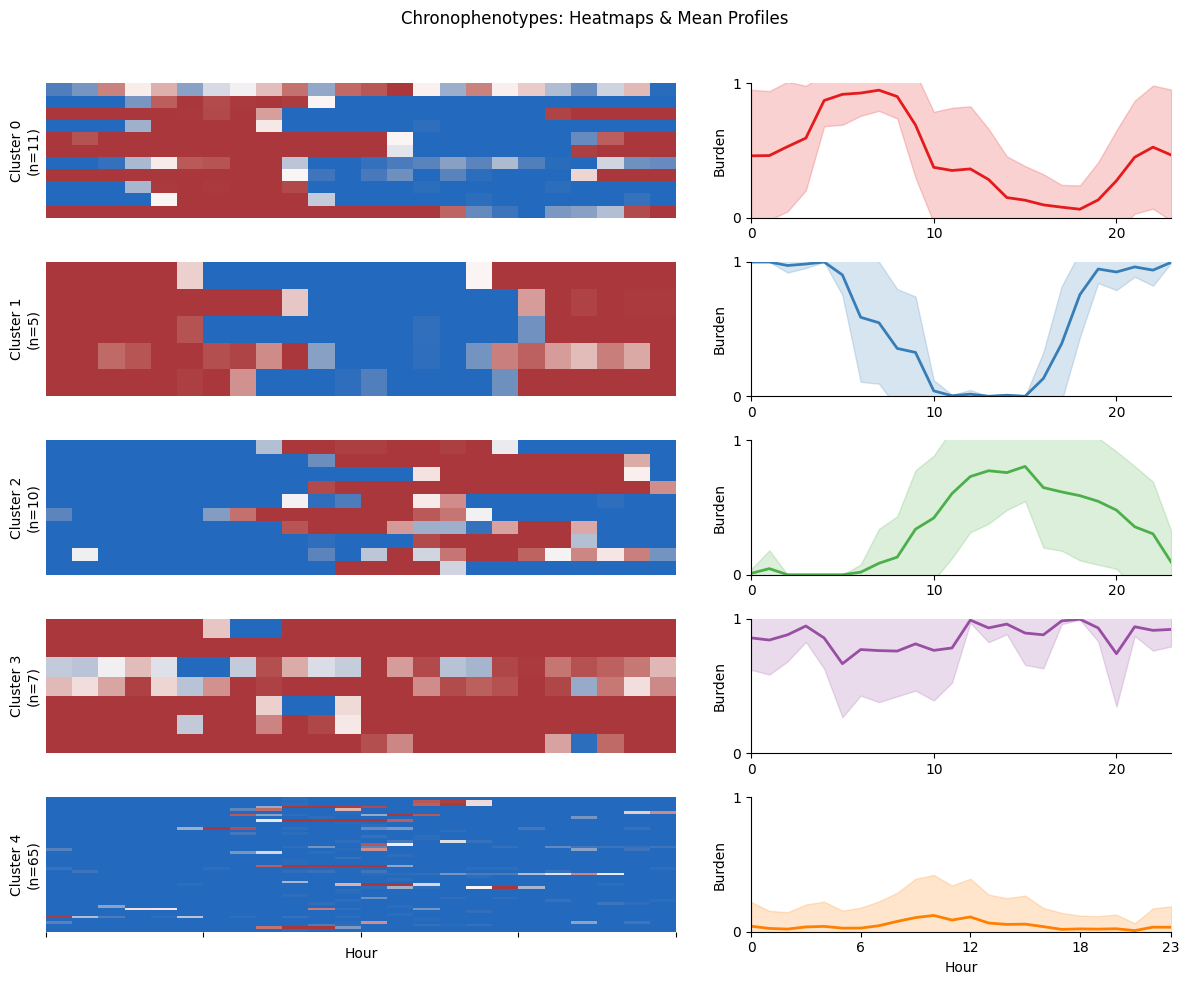

In [12]:
plots.plot_chronophenotypes_combined(
    burden_profiles.values,
    chronophenotypes['chronophenotype'].values,
    max_heatmap_samples=50,
    save_path=f"{FIGURES_DIR}/shdb_chronophenotypes_combined.png"
)
